In [ ]:
-

Implementación de Backpropagation y Funciones de Activación en Redes Neuronales en Google Colab

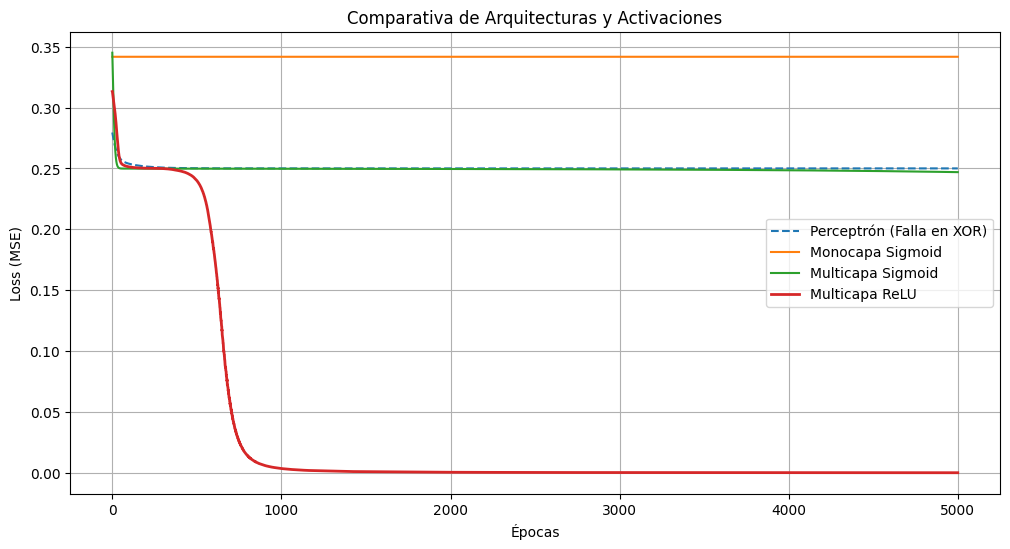

Precisión Perceptrón: 25.0%
Precisión Monocapa Sigmoid: 50.0%
Precisión Multicapa ReLU: 100.0%


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. DEFINICION DE FUNCIONES DE ACTIVACIÓN
def sigmoid(x):
  return 1 / (1 + np.exp(-x)) # función Sigmoide: comprime valores entre 0 y1, ideal para la capa de salidad binaria

def sigmoid_der(x):
  return x * (1 - x)        # derivada Sigmoide: calcula el gradiente de backpropagation

def relu(x):
  return np.maximum(0, x)    # funcion ReLU, devuelve 0 para valores negativos y x para positivos, evita el desvanecimiento del gradiente

def relu_der(x):
  return (x > 0).astype(float)  # derivada de ReLu: 1 para x > 0, de lo contrario 0

# 2. PREPARACIÓN DE DATASET (XOR) CLASIFICACION BINARIAS

# datos de entrenamiento usando (problema XOR)
# las entradas seran : [0,0], [0,1], [1,0], [1,1]
# las salidas seran: [0],[1],[1],[0]

X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0],[1],[1],[0]])

# 3. IMPLEMENTACIÓN DE LAS TRES ARQUITECTURAS (PERCENTRON, UNA CAPA, MULTICAPA)

  # ARQUITECTURA PERCEPTRÓN SIMPLE (sin capas ocultas)

def train_perceptron(epochs=5000, lr=0.1):
    np.random.seed(42)
    w = np.random.uniform(size=(2, 1))
    b = np.zeros((1, 1))
    loss_history = []
    for _ in range(epochs):
        z = np.dot(X, w) + b
        a = sigmoid(z)
        error = y - a
        loss_history.append(np.mean(np.square(error)))
        # Backpropagation simple (calculo de gradiente y actualización)
        d_a = error * sigmoid_der(a)
        w += X.T.dot(d_a) * lr
        b += np.sum(d_a, axis=0, keepdims=True) * lr
    return loss_history, a

# ARQUITECTURA RED MONOCAPA
# ahora haremos la funcion de entrenamiento (Backpropagation manual)

def train_monocapa(activation_func, activation_der, epochs=5000, lr=0.1):
    np.random.seed(42)
    w1 = np.random.uniform(size = (2, 4))
    b1 = np.zeros((1, 4))
    w2 = np.random.uniform(size=(4, 1))
    b2 = np.zeros((1,1))
    loss_history = []

    for _ in range(epochs):
        # Forward
        a1 = activation_func(np.dot(X, w1) + b1)
        a2 = sigmoid(np.dot(a1, w2) + b2)
        error = y - a2
        loss_history.append(np.mean(np.square(error)))

  # Backpropagation
    d_a2 = error *sigmoid_der(a2)  # Gradiente en la capa de salida (error multicapa * la pendiente de la activacion)
    d_a1 = d_a2.dot(w2.T) * activation_der(a1) # propagación del error hacia la capa oculta

  # actualización de parametros (Gradiente Descendente)
    w2 += a1.T.dot(d_a2) * lr
    b2 += np.sum(d_a2, axis=0, keepdims=True) * lr
    w1 += X.T.dot(d_a1) * lr
    b1 += np.sum(d_a1, axis=0, keepdims=True) * lr
    return loss_history, a2

  # ARQUITECTURA C: Red Multicapa (2 capas ocultas)
def train_multicapa(activation_func, activation_der, epochs=5000, lr=0.1):
    np.random.seed(42)
    # Pesos para 3 niveles: Input(2) -> H1(4) -> H2(4) -> Output(1)
    w1, b1 = np.random.uniform(size=(2, 4)), np.zeros((1, 4))
    w2, b2 = np.random.uniform(size=(4, 4)), np.zeros((1, 4))
    w3, b3 = np.random.uniform(size=(4, 1)), np.zeros((1, 1))
    loss_history = []

    for _ in range(epochs):
        a1 = activation_func(np.dot(X, w1) + b1)
        a2 = activation_func(np.dot(a1, w2) + b2)
        a3 = sigmoid(np.dot(a2, w3) + b3)

        error = y - a3
        loss_history.append(np.mean(np.square(error)))

        # Backpropagation en cadena
        d_a3 = error * sigmoid_der(a3)
        d_a2 = d_a3.dot(w3.T) * activation_der(a2)
        d_a1 = d_a2.dot(w2.T) * activation_der(a1)

        # actualización de pesos y sesgos
        w3 += a2.T.dot(d_a3) * lr
        b3 += np.sum(d_a3, axis=0, keepdims=True) * lr
        w2 += a1.T.dot(d_a2) * lr
        b2 += np.sum(d_a2, axis=0, keepdims=True) * lr
        w1 += X.T.dot(d_a1) * lr
        b1 += np.sum(d_a1, axis=0, keepdims=True) * lr
    return loss_history, a3

# MÉTRICA Y EJECUCIÓN
# entrenamiento del modelo
def calcular_precision(predicciones, reales):
    # Convertimos probabilidades a 0 o 1 (umbral 0.5)
    binarias = (predicciones > 0.5).astype(int)
    return np.mean(binarias == reales) * 100

# entrenamiento
loss_perc, res_perc = train_perceptron()
loss_mono_sig, res_mono_sig = train_monocapa(sigmoid, sigmoid_der)
loss_multi_sig, res_multi_sig = train_multicapa(sigmoid, sigmoid_der)
loss_multi_relu, res_multi_relu = train_multicapa(relu, relu_der)

  #  VISUALIZACIÓN Y COMPARATIVAS

plt.figure(figsize=(12, 6))
plt.plot(loss_perc, label='Perceptrón (Falla en XOR)', linestyle='--')
plt.plot(loss_mono_sig, label='Monocapa Sigmoid')
plt.plot(loss_multi_sig, label='Multicapa Sigmoid')
plt.plot(loss_multi_relu, label='Multicapa ReLU', linewidth=2)
plt.title('Comparativa de Arquitecturas y Activaciones')
plt.xlabel('Épocas'); plt.ylabel('Loss (MSE)'); plt.legend(); plt.grid(True); plt.show()

print(f"Precisión Perceptrón: {calcular_precision(res_perc, y)}%")
print(f"Precisión Monocapa Sigmoid: {calcular_precision(res_mono_sig, y)}%")
print(f"Precisión Multicapa ReLU: {calcular_precision(res_multi_relu, y)}%")







Markdown

1. ¿Que cambio al variar la activación?

El cambio más fuerte fue ver cómo ReLU superó por mucho a Sigmoid en la red multicapa.

Mientras que con Sigmoid el aprendizaje se siente "frenado" porque los gradientes se vuelven muy pequeños, ReLU permite que la señal del error pase con más fuerza. Gracias a esto, el modelo logró entender la lógica del problema XOR en menos de 1,000 épocas, algo que a las otras versiones les costó mucho más o simplemente no lograron

2. Como se comportó el loss/métrica.

 Bueno aqui el grafico muestra que :

- Perceptrón Simple: El Loss se estancó rápidamente en 0.25 y la precisión no pasó del 25-50%. Esto confirmó la teoría: un modelo lineal no puede resolver un problema no lineal como XOR.

- Red Monocapa (Sigmoid): Aunque tiene capacidad teórica para resolverlo, el Loss bajó muy lentamente. Esto demuestra que la arquitectura por sí sola no basta; necesita una configuración de pesos iniciales muy precisa o más iteraciones para converger.

- Red Multicapa (ReLU): Es la única que mostró una "curva de aprendizaje" clara. El error cae drásticamente cuando la red encuentra la combinación correcta de pesos, alcanzando una precisión del 100%.


3. Principales dificultades o hallazgos.

Los detalles: al programar backpropagation desde cero, un simple error al escribir, como colocar square en lugar de square, detiene todo el proceso. esto me enseño lo sensible que es la implementación mataemática manual.

Es sorprendente ver como una arquitectura tan pequeña solo con 4 neuronas ocultas, cambia tanto su desempeño solo con cambier la función de activación. ReLu realmente hace que el entrenamiento sea más eficiente incluso en problemas simples.

Conclusión general

Dificultades: Lo más complejo fue hacer el backpropagation manual. Lograr que las dimensiones de las matrices coincidieran (usando .T y .dot) para que el error fluyera correctamente de una capa a otra.

Hallazgos: Se confirma que para problemas como XOR, no basta con entrenar por muchas épocas; si la arquitectura o la función de activación no son las adecuadas, el modelo simplemente se queda "atascado" sin aprender nada nuevo
